------ Challenge Econometría -------

Mateo Cabré
UADE


         Beta
B0  12.679913
B1  -1.300675
B2  -0.142971
B3   0.073441
B4   0.005814
----------------------------
   intercepto        x1            x2        x3            x4
0    0.066372 -0.007299 -5.777313e-04  0.002413 -6.332679e-05
1   -0.007299  0.000813  4.306138e-05 -0.000265  6.640815e-06
2   -0.000578  0.000043  4.721980e-05 -0.000020  4.564053e-07
3    0.002413 -0.000265 -1.955480e-05  0.000103 -2.952919e-06
4   -0.000063  0.000007  4.564053e-07 -0.000003  2.475279e-07
----------------------------
[ 49.21798578 -45.60460176 -20.80582558   7.24037744  11.68545685]
----------------------------
        p-valor
0  0.000000e+00
1  0.000000e+00
2  0.000000e+00
3  7.811529e-13
4  0.000000e+00
----------------------------
Los R2 y R2 ajustados respectivamente son: 0.8919 0.89147


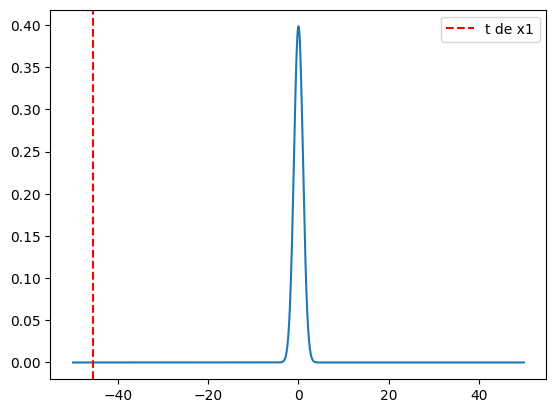

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
from scipy import stats
from scipy.stats import t


y = pd.read_csv('spreads.csv')
x1 = pd.read_csv('SP500.csv')
x2 = pd.read_csv('DGS10.csv')
x3 = pd.read_csv('T10Y2Y.csv')
x4 = pd.read_csv('VIXCLS.csv')
y.set_index('observation_date', inplace=True)
x1.set_index('observation_date', inplace=True)
x2.set_index('observation_date', inplace=True)
x3.set_index('observation_date', inplace=True)
x4.set_index('observation_date', inplace=True)

df = y.join([x1, x2, x3, x4], how='inner')

# primer intento de crear la matrix x'x
df = df.dropna()
df_numpy = df.values
df_numpy[:, 1] = np.log(df_numpy[:, 1])
vector_y = df_numpy[:, 0]
matriz_x = df_numpy[:, 1:5]
unos = np.ones(matriz_x.shape[0])
matriz_x = np.column_stack((unos, matriz_x))
x_transpuesta = np.transpose(matriz_x)
matriz_x_grande = np.dot(x_transpuesta, matriz_x)
matriz_inversa = np.linalg.inv(matriz_x_grande)
matriz_xy = x_transpuesta @ vector_y

estimadores = (matriz_inversa @ matriz_xy)
print(pd.DataFrame(estimadores, columns=['Beta'], index= ['B0', 'B1', 'B2', 'B3', 'B4']))
print("----------------------------")
y_estimados = matriz_x @ estimadores

residuos_cuadrado = (vector_y - y_estimados) ** 2

scr = np.sum(residuos_cuadrado)

var_pertubaciones = scr / (1250-5)
matriz_var_cov = var_pertubaciones * matriz_inversa

# imprimamoslo en pandas
matriz_varcov_pandas = pd.DataFrame(matriz_var_cov, columns=['intercepto', 'x1', 'x2', 'x3' ,'x4',])

print(matriz_varcov_pandas)

desvios_estimadores = np.sqrt(matriz_var_cov.diagonal())

print("----------------------------")

t_estadisticos = estimadores / desvios_estimadores

print(t_estadisticos)
print("----------------------------")

p_valores = 2 * (1- stats.t.cdf(abs(t_estadisticos), 1245))

print(pd.DataFrame(p_valores, columns=["p-valor"]))
print("----------------------------")

sct = np.sum((vector_y - np.mean(vector_y))**2)
r_cuadrado = 1- (scr/sct)
r_cuadrado_aj = 1- (1-r_cuadrado) * (1250/1245)

print("Los R2 y R2 ajustados respectivamente son:", round(r_cuadrado, 5), round(r_cuadrado_aj, 5))


x = np.linspace(-50, 50, 1000) 
y = t.pdf(x, df=1245)

plt.plot(x, y)
plt.axvline(x=-45.6, color='red', linestyle='--', label='t de x1')
plt.legend()
plt.show()